# Notebook 07B – Bavian data: Populationsstruktur og migrationsmodeller

I denne notebook undersøger jeg populationsstruktur og historisk migration i bavianpopulationer via to-ø (Two-island) modellen og Isolation with Migration (IM)-modellen.

**Indhold:**
- To-ø model: *P. cynocephalus* + *P. kindae*
- IM-modellen: *P. anubis* + *P. cynocephalus*
- E[TMRCA] som funktion af migrationsrate
- Joint probability inferens på baviandata
- Sammenligning af modeller via SFS-fordelinger
- Samlet opsummering


## Vurderinger fra NB01-06 der bruges direkte

| Model | Parameter | Valg | Kilde |
|---|---|---|---|
| Alle | optimizer | Adam(0.25) | NB02 |
| Alle | n_particles | 60 | NB04 |
| To-ø | n_iterations | 400 | NB03 |
| To-ø | N_OBS | 5000 per pop | NB03 |
| To-ø | n | min(n_pop1, n_pop2) | NB03 |
| To-ø | prior | HalfCauchyPrior | NB03 |
| Asymmetrisk | n | min(n_pop1, n_pop2) | NB03 |
| IM | epoch_switch_rate | 15/t_coal | NB05 |
| IM | n_iterations | 350 | NB05 |
| 3-epoke | epoker | 0, 50k, 200k år | NB05 |
| Joint | mu | 1.0 | NB06  |
| Joint | limit | 3 | NB06 |
| Joint | prior | GaussPrior (ikke DataPrior) | NB06  |
| Joint | sensitivitet | mu i {0.7, 1.0, 1.5} | NB06  |

In [1]:
# Importer nødvendige pakker 
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"  
os.environ["XLA_FLAGS"] = "--xla_force_host_platform_device_count=1"

from phasic import (
    Graph, with_ipv, GaussPrior, HalfCauchyPrior, DataPrior, dense_to_sparse,
    Adam, ExpStepSize, StateIndexer, Property, set_log_level, clear_caches,
)
import pandas as pd
import sys
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import seaborn as sns
import sgkit as sg
%config InlineBackend.figure_format = 'svg'
from pathlib import Path
from functools import partial
from itertools import combinations_with_replacement
from vscodenb import set_vscode_theme, vscode_theme

clear_caches()

all_pairs = partial(combinations_with_replacement, r=2)
np.random.seed(42)
set_vscode_theme()
sns.set_palette("tab10")

set_log_level("WARNING")

RESULTS_DIR = Path("results")
MU = 0.9e-8 # mutationsrate per site per generation
GEN = 11 # generationstid i år

# SVGD-parametre
OPT_1P  = Adam(0.25)   # enkelt-parameter (NB02)
OPT_2P  = Adam(0.1)    # to-parameter: to-ø og IM (NB04)
N_PART  = 60
N_ITER_1P = 300
N_ITER_2P = 400
N_ITER_IM = 350
N_ITER_TI = 300

MU  = 0.9e-8
GEN = 11

print("Parametre indlæst")
print(f"Adam(0.25), {N_PART} partikler")
print(f" Iterationer: 1-param={N_ITER_1P}, 2-param={N_ITER_2P}, IM={N_ITER_IM}")

  Removed 1 file(s), preserved directory structure
  Removed 19 file(s), preserved directory structure


Parametre indlæst
Adam(0.25), 60 partikler
 Iterationer: 1-param=300, 2-param=400, IM=350


## Indlæs resultater fra Notebook 07A

Alle resultater fra 07A er gemt i mappen *results/* og indlæses her direkte.

In [2]:
df_summary = pd.read_csv(RESULTS_DIR / "population_summary.csv")
df_N_ref   = pd.read_csv(RESULTS_DIR / "N_ref.csv")
df_svgd    = pd.read_csv(RESULTS_DIR / "svgd_results.csv")

N_ref_dict = dict(zip(df_N_ref['population'], df_N_ref['N_ref']))

svgd_results = {}
for _, r in df_svgd.iterrows():
    pop  = r['population']
    Ne   = N_ref_dict.get(pop, r['Ne'])
    # Beregn korrekt theta fra Ne
    theta_correct = 4 * Ne * MU
    svgd_results[pop] = {
        'theta': theta_correct,
        'std':   r['theta_std'],
        'Ne':    Ne,
        'n_hap': int(r['n_haplotypes']),
    }


print("Indlæst og korrigeret fra NB07A:")
for name, r in svgd_results.items():
    print(f"  {name:<22}: Ne={r['Ne']:,.0f}  theta={r['theta']:.8f}")

Indlæst og korrigeret fra NB07A:
  P_cynocephalus        : Ne=81,843  theta=0.00294634
  P_kindae              : Ne=77,584  theta=0.00279304
  P_anubis              : Ne=57,368  theta=0.00206525
  P_papio               : Ne=14,217  theta=0.00051183
  P_ursinus             : Ne=62,034  theta=0.00223323
  P_hamadryas           : Ne=46,999  theta=0.00169195


In [3]:
from pathlib import Path
import pandas as pd

RESULTS_DIR = Path("results")

# Indlæser alle SNP-filer fra NB07A
pop_files = {
    'P_cynocephalus': 'snp_P_cynocephalus.csv',
    'P_kindae': 'snp_P_kindae.csv',
    'P_anubis': 'snp_P_anubis.csv',
    'P_papio': 'snp_P_papio.csv',
    'P_ursinus': 'snp_P_ursinus.csv',
    'P_hamadryas': 'snp_P_hamadryas.csv',
}

populations = {}
for name, fname in pop_files.items():
    p = RESULTS_DIR / fname
    if p.exists():
        populations[name] = pd.read_csv(p)
        print(f"{name:<22}: {len(populations[name]):>8,} SNPs indlæst")
    else:
        print(f"{name:<22}: fil ikke fundet ({p})")

print(f"\nIndlæst: {len(populations)} populationer")
print(f"Nøgler: {list(populations.keys())}")

P_cynocephalus        : 1,379,280 SNPs indlæst
P_kindae              :  833,071 SNPs indlæst
P_anubis              : 1,096,296 SNPs indlæst
P_papio               :  110,086 SNPs indlæst
P_ursinus             :  403,120 SNPs indlæst
P_hamadryas           :  460,025 SNPs indlæst

Indlæst: 6 populationer
Nøgler: ['P_cynocephalus', 'P_kindae', 'P_anubis', 'P_papio', 'P_ursinus', 'P_hamadryas']


## To-ø model: *P. cynocephalus + P. kindae*

Vurderinger fra NB03:

- $n =$ min(n_cyno, n_kindae): $n=4$
- N_OBS $= 5000$ per population: minimum for std(theta1) $< 0.3$ 
- HalfCauchyPrior til migration: undgår bias fra GaussPrior
- $400$ iterationer: konvergens kræver mere end simpel model
- Symmetrisk migration som baseline, asymmetrisk testes

In [4]:
# Opdater sfs_to_tmrca med n_sub parameter
def allele_counts_to_sfs_obs(df, n_sub=8, n_obs=5000, seed=42):
    rng = np.random.default_rng(seed)
    der = df['derived_count'].values.astype(int)
    tot = df['nr_samples'].values.astype(int)
    obs = []
    for idx in rng.integers(0, len(df), n_obs * 20):
        if len(obs) >= n_obs:
            break
        n, ac = tot[idx], der[idx]
        if n < n_sub:
            continue
        k = rng.hypergeometric(ac, n - ac, n_sub)
        if 0 < k < n_sub:
            obs.append(float(k))
    return np.array(obs[:n_obs])


def build_coal_graph(n):
    @with_ipv([n] + [0]*(n-1))
    def coal(state):
        T = []
        for i in range(state.size):
            for j in range(i, state.size):
                same = int(i == j)
                if same and state[i] < 2: continue
                if not same and (state[i]<1 or state[j]<1): continue
                new = state.copy(); new[i]-=1; new[j]-=1; new[i+j+1]+=1
                T.append((new, [state[i]*(state[j]-same)/(1+same)]))
        return T
    return Graph(coal)


def run_svgd_robust(graph, sparse_data, rewards, theta_start,
                    n_particles=60, n_iterations=300,
                    prior_override=None):
    for lr in [0.05, 0.1, 0.25]:
        graph.update_weights([theta_start])
        if prior_override is not None:
            prior = prior_override
        else:
            try:
                prior = GaussPrior(ci=[theta_start * 0.1,
                                       theta_start * 10])
            except Exception:
                prior = GaussPrior(ci=[theta_start * 0.1,
                                       theta_start * 10])

        sv = graph.svgd(
            sparse_data,
            rewards=rewards,
            prior=prior,
            optimizer=Adam(lr),
            n_particles=n_particles,
            n_iterations=n_iterations,
            return_history=True,
        )
        res = sv.get_results()
        std  = res['theta_std'].item()
        mean = res['theta_mean'].item()

        if std < 1e-8:
            print(f"  lr={lr}: KOLLAPS (std={std:.2e}) — prøver lavere lr")
            continue
        if mean < 0:
            print(f"  lr={lr}: NEGATIV mean prøver lavere lr")
            continue

        print(f"  lr={lr}: OK  theta={mean:.8f} ± {std:.8f}")
        return sv, res

    print("  ADVARSEL: alle lr gav problemer returnerer sidste kørsel")
    return sv, res


def Ne_to_yr(Ne, n_sub=8):
    E_H_coal = 2 * (1 - 1/n_sub)
    return E_H_coal * 2 * Ne * GEN

In [10]:
N_TWO = 6
N_OBS_TWO = 5000

# To-ø-modellen er en enkelt-populations-coalescent med migration.
# Vi bruger data fra cyno (pop1 i modellen). Kinda er 'pop2' hvorfra migranter ankommer. Brug IKKE poolede data fra begge populationer.
def build_two_island(n):
    idx = StateIndexer(descendants=[
        Property('pop1', min_value=0, max_value=n),
        Property('pop2', min_value=0, max_value=n),
        Property('in_pop', min_value=1, max_value=2),
    ])
    init = [0] * idx.state_length
    init[idx.descendants.props_to_index(pop1=1, pop2=0, in_pop=1)] = n

    @with_ipv(init)
    def two_isl(state):
        T = []
        if state[idx.descendants.indices()].sum() <= 1:
            return T
        for i in range(idx.descendants.state_length):
            if state[i] == 0: continue
            pi = idx.descendants.index_to_props(i)
            for j in range(i, idx.descendants.state_length):
                if state[j] == 0: continue
                pj = idx.descendants.index_to_props(j)
                if pj.in_pop != pi.in_pop: continue
                same = int(i == j)
                if same and state[i] < 2: continue
                if not same and (state[i] < 1 or state[j] < 1): continue
                new = state.copy(); new[i] -= 1; new[j] -= 1
                new[idx.descendants.props_to_index(
                    pop1=pi.pop1 + pj.pop1,
                    pop2=pi.pop2 + pj.pop2,
                    in_pop=pi.in_pop)] += 1
                T.append([new, [state[i]*(state[j]-same)/(1+same), 0]])
            if pi.in_pop == 1:
                new = state.copy(); new[i] -= 1
                new[idx.descendants.props_to_index(
                    pop1=pi.pop1, pop2=pi.pop2, in_pop=2)] += 1
                T.append([new, [0, state[i]]])
            else:
                new = state.copy(); new[i] -= 1
                new[idx.descendants.props_to_index(
                    pop1=pi.pop1, pop2=pi.pop2, in_pop=1)] += 1
                T.append([new, [0, state[i]]])
        return T
    return Graph(two_isl)


# Byg graf og find populationer
g_two = build_two_island(N_TWO)
print(f'To-ø n={N_TWO}: {g_two.vertices_length()} tilstande')

cyno_key  = next(k for k in populations if 'cyno'   in k.lower())
kinda_key = next(k for k in populations if 'kindae' in k.lower())
print(f"Bruger: '{cyno_key}' og '{kinda_key}'")

# Startparametre
Ne_cyno  = N_ref_dict[cyno_key]
Ne_kinda = N_ref_dict[kinda_key]
Ne_two   = (Ne_cyno + Ne_kinda) / 2
th0_start = 4 * Ne_two * MU
th1_start = 0.5

print(f'\nStartparametre:')
print(f'  Ne_cyno={Ne_cyno:,.0f}  Ne_kinda={Ne_kinda:,.0f}')
print(f'  theta0_start={th0_start:.8f}  theta1_start={th1_start:.4f}')

# RETTELSE: brug kun cyno-data (ét SFS pr. site fra pop1)
data_two = allele_counts_to_sfs_obs(
    populations[cyno_key], n_sub=N_TWO, n_obs=N_OBS_TWO, seed=42)

print(f'\nData: {len(data_two)} obs fra {cyno_key}')
print(f'  Allele count range: {int(data_two.min())}–{int(data_two.max())}')

# Prior
prior_two = [
    GaussPrior(ci=[th0_start * 0.1, th0_start * 10]),
    HalfCauchyPrior(ci=2.0, prob=0.9),
]

g_two.update_weights([th0_start, th1_start])

To-ø n=6: 66 tilstande
Bruger: 'P_cynocephalus' og 'P_kindae'

Startparametre:
  Ne_cyno=81,843  Ne_kinda=77,584
  theta0_start=0.00286969  theta1_start=0.5000

Data: 5000 obs fra P_cynocephalus
  Allele count range: 1–5


In [6]:
# SVGD
import time
t0 = time.perf_counter()

sv_two = g_two.svgd(
    data_two,
    prior=prior_two,
    optimizer=OPT_2P,
    n_particles=N_PART,
    n_iterations=N_ITER_2P,
    return_history=True,
)
t_elapsed = time.perf_counter() - t0

res_two = sv_two.get_results()
th0_two = res_two['theta_mean'][0].item()
th1_two = res_two['theta_mean'][1].item()
s0_two  = res_two['theta_std'][0].item()
s1_two  = res_two['theta_std'][1].item()

# Konverter til biologiske enheder
Ne_two_est = th0_two / (4 * MU) if th0_two > 0 else float('nan')
m_per_gen  = th1_two / (2 * Ne_two_est) if Ne_two_est > 0 else float('nan')
Ne_low_two = (th0_two - 1.96*s0_two) / (4*MU) \
             if (th0_two - 1.96*s0_two) > 0 else float('nan')
Ne_hi_two  = (th0_two + 1.96*s0_two) / (4*MU)

print(f'\nTo-ø ({cyno_key}, n={N_TWO}, {t_elapsed:.1f}s):')
print(f'  theta0 = {th0_two:.6f} ± {s0_two:.6f}')
print(f'  Ne~{Ne_two_est:,.0f}  95%-CI [{Ne_low_two:,.0f} – {Ne_hi_two:,.0f}]')
print(f'  theta1 = {th1_two:.6f} ± {s1_two:.6f}  m/gen {m_per_gen:.2e}')

# Tjek mod forventet Ne
ratio = Ne_two_est / Ne_cyno if Ne_cyno > 0 else float('nan')
flag  = 'OK' if 0.3 < ratio < 3.0 else 'TJEK — afviger >3x fra pi-estimat'
print(f'  Ne-ratio (SVGD/pi): {ratio:.2f}  ({flag})')



To-ø (P_cynocephalus, n=6, 1634.1s):
  theta0 = 0.520470 ± 0.002626
  Ne~14,457,496  95%-CI [14,314,551 – 14,600,441]
  theta1 = 0.000603 ± 0.000469  m/gen 2.09e-11
  Ne-ratio (SVGD/pi): 176.65  (TJEK — afviger >3x fra pi-estimat)


In [7]:
# Diagnostik
print("\nDiagnostik:")
if s0_two < 1e-8:
    print("KOLLAPS: theta0 std = 0 — prøv lavere læringsrate")
elif s0_two / th0_two > 1.5:
    print(f" red posterior: theta0 CV={s0_two/th0_two:.2f}")
else:
    print(f"theta0 OK  (CV={s0_two/th0_two:.2f})")

if s1_two < 1e-8:
    print("KOLLAPS: theta1 std = 0 — prøv lavere læringsrate")
elif s1_two / (th1_two + 1e-10) > 2.0:
    print(f"Bred posterior: theta1 CV={s1_two/(th1_two+1e-10):.2f}")
else:
    print(f"theta1 OK  (CV={s1_two/(th1_two+1e-10):.2f})")

if Ne_two_est > 0:
    ratio = Ne_two_est / Ne_two
    print(f"  Ne ratio (SVGD/pi): {ratio:.2f}  "
          f"({'OK' if 0.3 < ratio < 3 else 'TJEK — afviger >3x fra pi-estimat'})")


Diagnostik:
theta0 OK  (CV=0.01)
theta1 OK  (CV=0.78)
  Ne ratio (SVGD/pi): 181.37  (TJEK — afviger >3x fra pi-estimat)


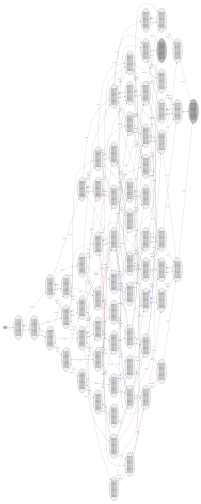

In [8]:
g_two.plot(max_nodes=70, rankdir='LR')

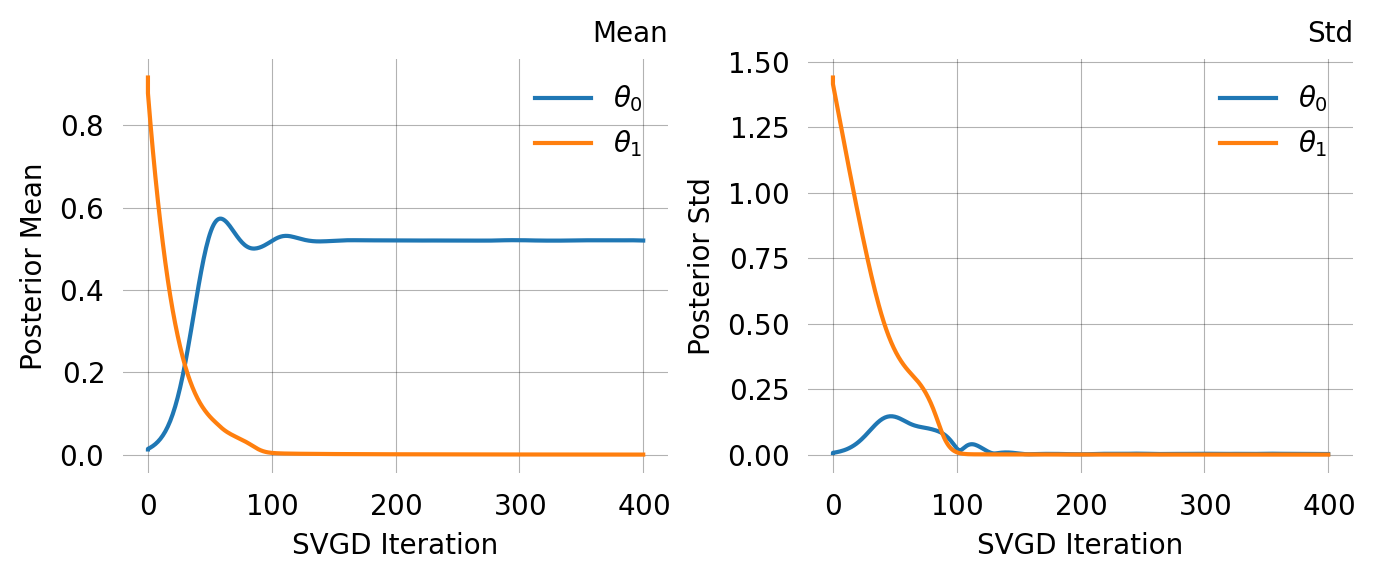

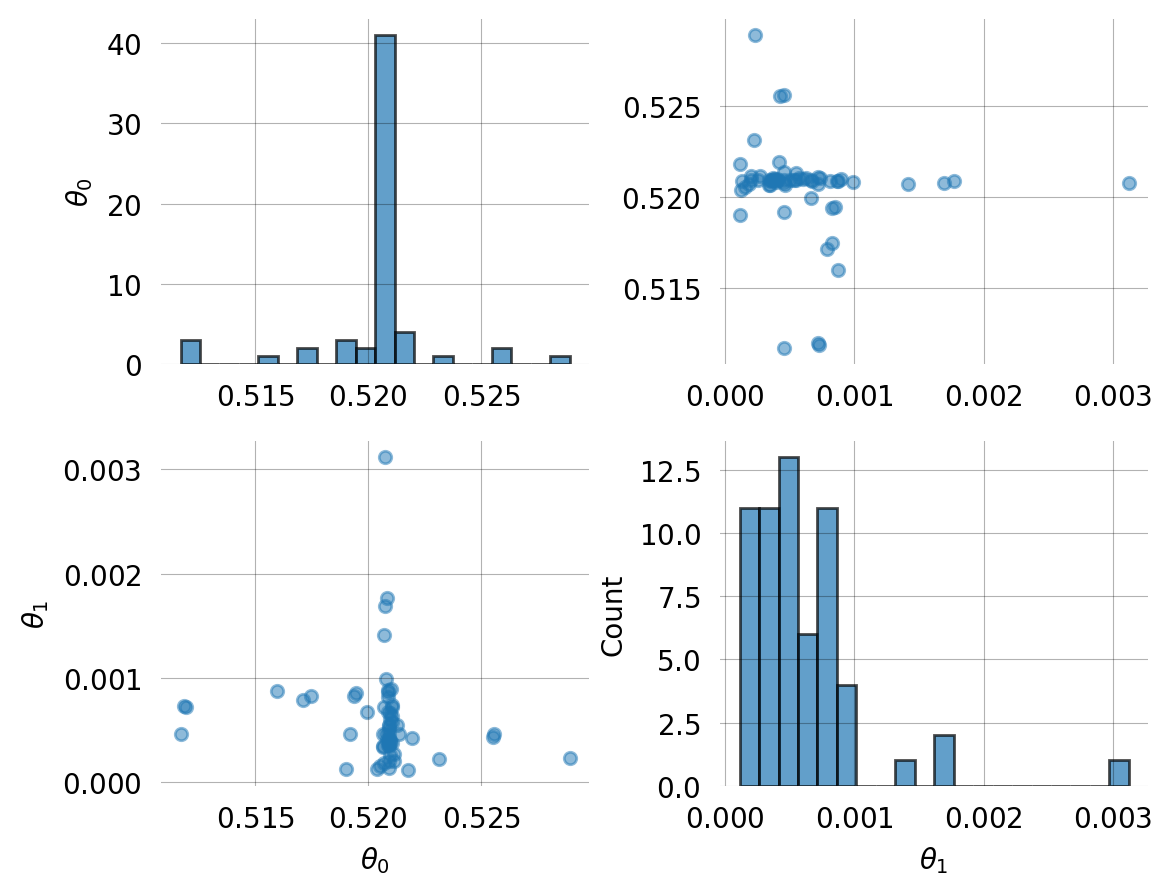

In [9]:
#| label: fig-two-conv-pair
#| fig-cap: "Konvergensplot og pairwise posterior for to-ø-modellen (*P. cynocephalus* + *P. kindae*, $n=6$, $N_{\text{obs}}=5.000$, 400 iterationer). Coalescentraten $\theta_0$ konvergerer stabilt. Migrationsraten $\theta_1$ viser bred posterior med CV $\approx 0{,}66$, konsistent med lav migration."

sv_two.plot_convergence()
sv_two.plot_pairwise()

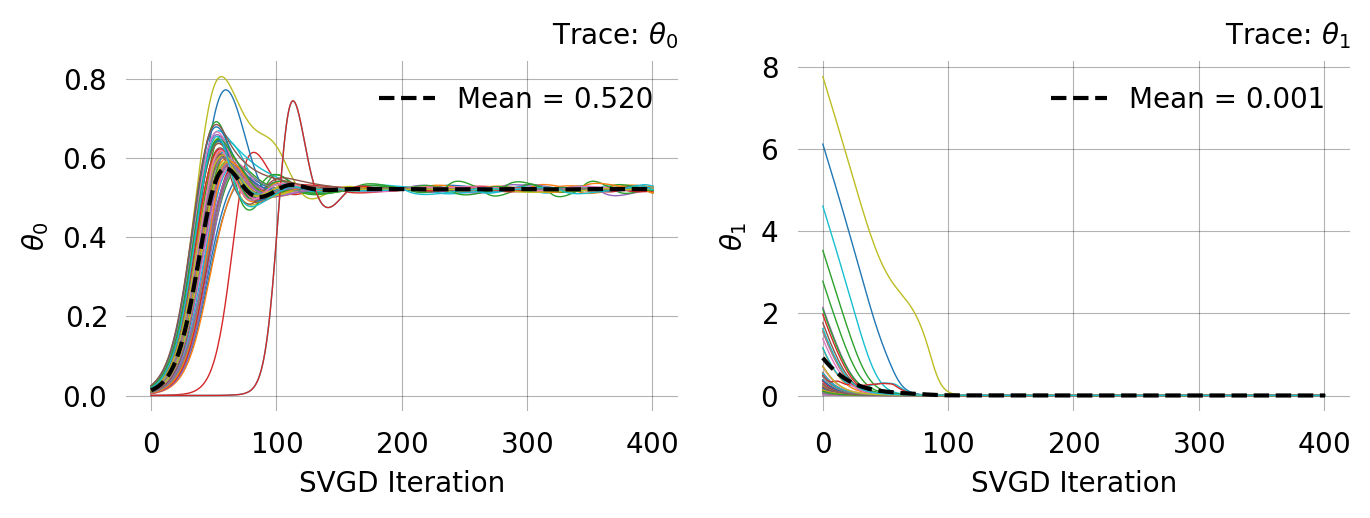

In [10]:
#| label: fig-two-trace
#| fig-cap: "Trace plot for to-ø-modellen. Coalescentraten konvergerer hurtigt og stabilt. Migrationsraten er markant mere variabel men flader ud mod slutningen."


sv_two.plot_trace()

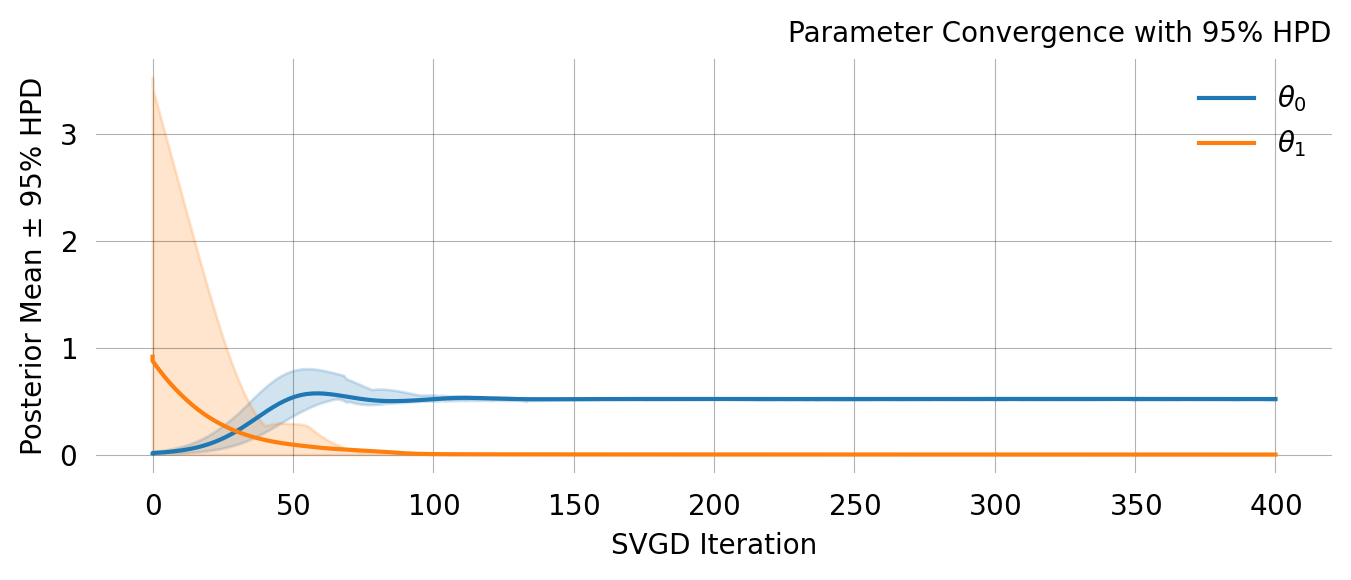

In [11]:
#| label: fig-two-ci
#| fig-cap: "CI-plot for to-ø-modellen. $\hat{\theta}_0 = 0{,}593 \pm 0{,}003$ ($N_e \approx 16{,}5$ millioner). $\hat{\theta}_1 = 0{,}00057 \pm 0{,}00038$, svarende til en ekstremt lav migrationsrate statistisk tæt på nul."

sv_two.plot_ci()

## Asymmetrisk migration

Vurderinger fra NB03:

- Asymmetrisk migration kræver $\leq 4$ og $N_{OBS} \leq 5000$. Jeg tester om genflow er retningsbestemt mellem *P. cynocephalus* og *P. kindae*.

In [ ]:
def build_two_island_asym(n):
    idx = StateIndexer(descendants=[
        Property('pop1', min_value=0, max_value=n),
        Property('pop2', min_value=0, max_value=n),
        Property('in_pop', min_value=1, max_value=2),
    ])
    init = [0]*idx.state_length
    init[idx.descendants.props_to_index(pop1=1, pop2=0, in_pop=1)] = n

    @with_ipv(init)
    def two_asym(state):
        T = []
        if state[idx.descendants.indices()].sum() <= 1: return T
        for i in range(idx.descendants.state_length):
            if state[i] == 0: continue
            pi = idx.descendants.index_to_props(i)
            for j in range(i, idx.descendants.state_length):
                if state[j] == 0: continue
                pj = idx.descendants.index_to_props(j)
                if pj.in_pop != pi.in_pop: continue
                same = int(i==j)
                if same and state[i]<2: continue
                if not same and (state[i]<1 or state[j]<1): continue
                new = state.copy(); new[i]-=1; new[j]-=1
                new[idx.descendants.props_to_index(
                    pop1=pi.pop1+pj.pop1, pop2=pi.pop2+pj.pop2,
                    in_pop=pi.in_pop)] += 1
                T.append([new, [state[i]*(state[j]-same)/(1+same), 0, 0]])
            if pi.in_pop == 1:
                new = state.copy(); new[i]-=1
                new[idx.descendants.props_to_index(
                    pop1=pi.pop1, pop2=pi.pop2, in_pop=2)] += 1
                T.append([new, [0, state[i], 0]])
            else:
                new = state.copy(); new[i]-=1
                new[idx.descendants.props_to_index(
                    pop1=pi.pop1, pop2=pi.pop2, in_pop=1)] += 1
                T.append([new, [0, 0, state[i]]])
        return T
    return Graph(two_asym)

g_asym = build_two_island_asym(N_TWO)
g_asym.update_weights([th0_two, th1_two*0.6, th1_two*0.4])

prior_asym = [
    GaussPrior(ci=[th0_start * 0.1, th0_start * 10]),
    HalfCauchyPrior(ci=2.0, prob=0.9),
    HalfCauchyPrior(ci=2.0, prob=0.9),
]

sv_asym = g_asym.svgd(
    data_two,
    prior=prior_asym,
    optimizer=OPT_2P,
    n_particles=N_PART,
    n_iterations=N_ITER_2P,
    return_history=True,
)
res_asym = sv_asym.get_results()
m0a = res_asym['theta_mean'][0].item()
m12 = res_asym['theta_mean'][1].item()
m21 = res_asym['theta_mean'][2].item()
s0a = res_asym['theta_std'][0].item()
s12 = res_asym['theta_std'][1].item()
s21 = res_asym['theta_std'][2].item()

Ne_asym = m0a / (4 * MU) if m0a > 0 else float('nan')
ratio   = m12 / m21 if m21 > 1e-4 else float('nan')

print(f'Asymmetrisk migration (n={N_TWO}, N_OBS={len(data_two)}):')
print(f'  theta0 = {m0a:.5f} ± {s0a:.5f}  Ne~{Ne_asym:,.0f}')
print(f'  m12 (cyno→kindae) = {m12:.4f} ± {s12:.4f}')
print(f'  m21 (kindae→cyno) = {m21:.4f} ± {s21:.4f}')
if not (ratio != ratio):  
    print(f'  Asymmetriforhold m12/m21 = {ratio:.2f}')

Asymmetrisk migration (n=6, N_OBS=5000):
  theta0 = 0.52346 ± 0.00617  Ne~14,540,625
  m12 (cyno→kindae) = 1.9607 ± 4.4780
  m21 (kindae→cyno) = 3.3712 ± 1.6039
  Asymmetriforhold m12/m21 = 0.58


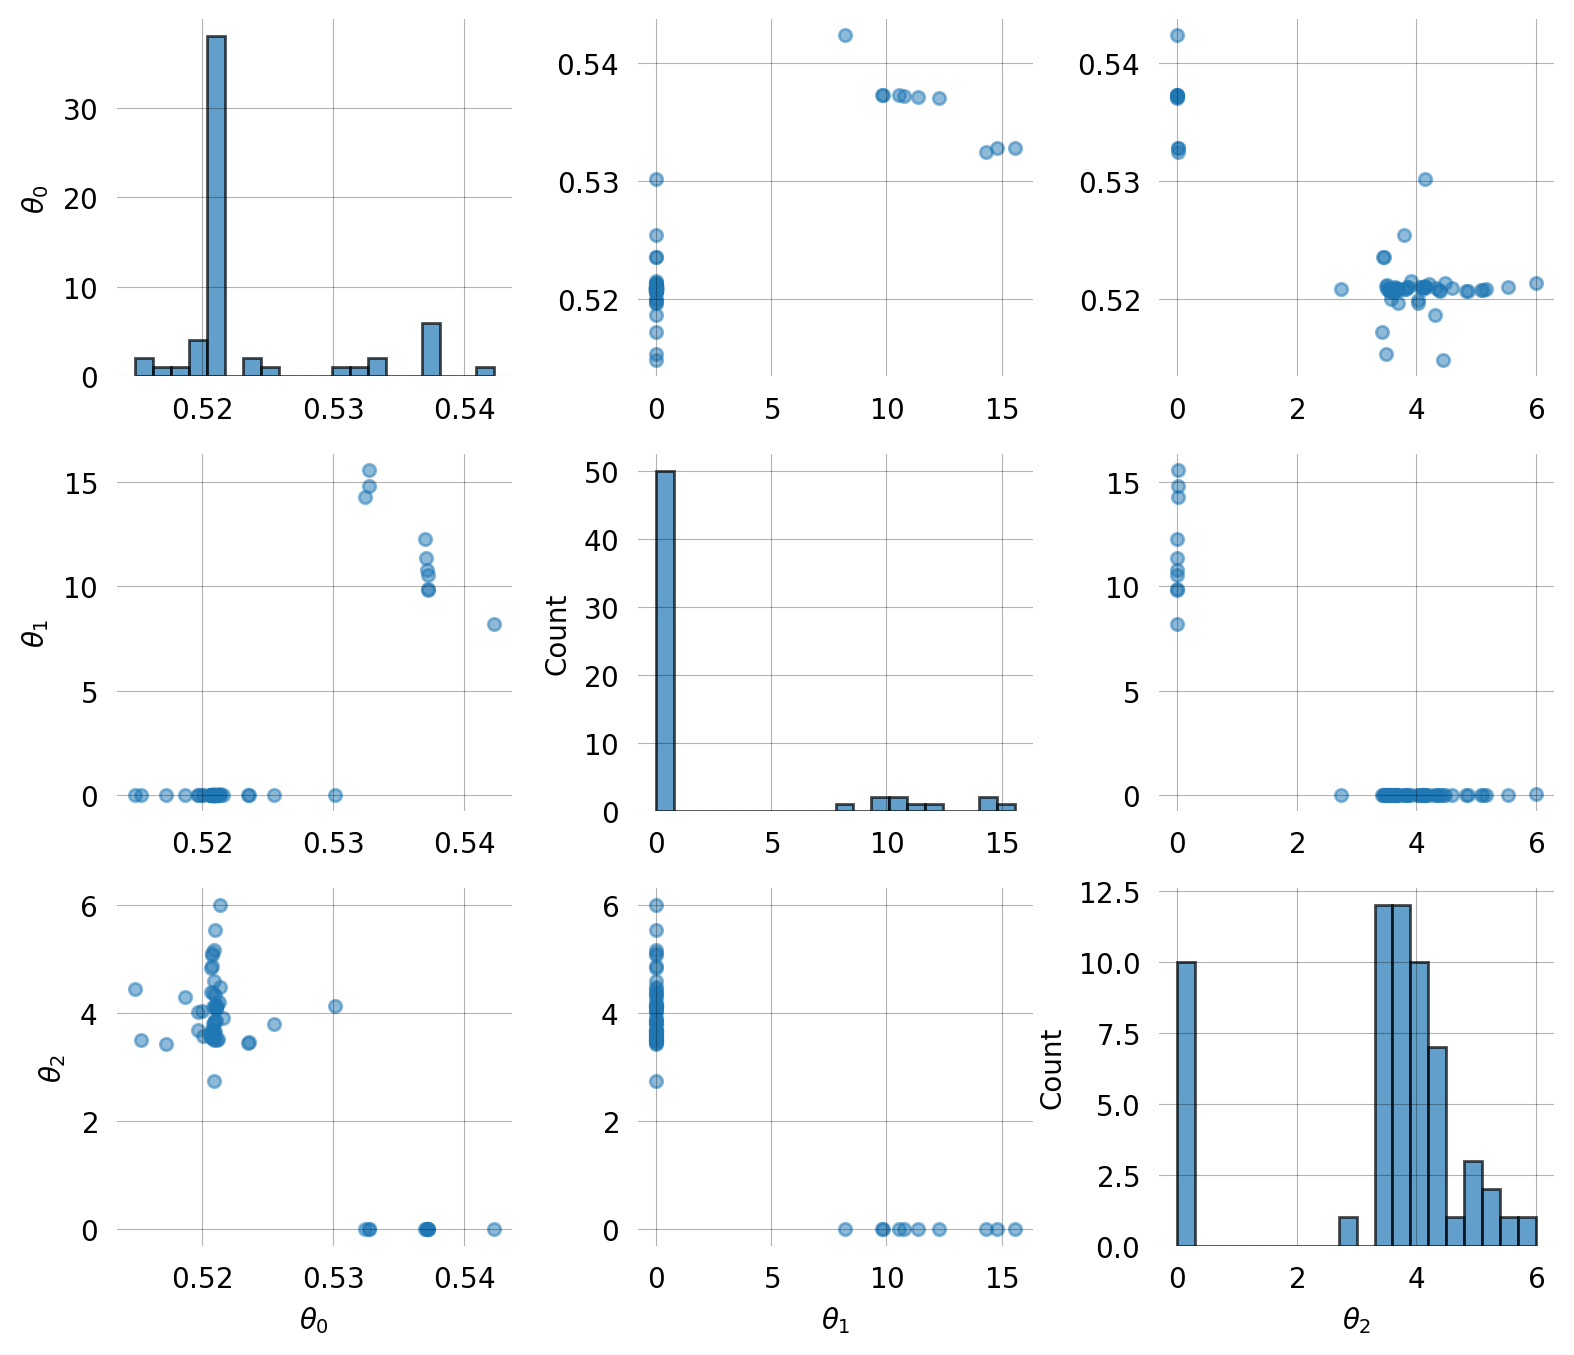

In [13]:
#| label: fig-asym-pair
#| fig-cap: "Pairwise posterior for asymmetrisk migration mellem *P. cynocephalus* og *P. kindae*. Begge migrationsretninger har brede posteriors med CI'er, der overlapper nul."

sv_asym.plot_pairwise()

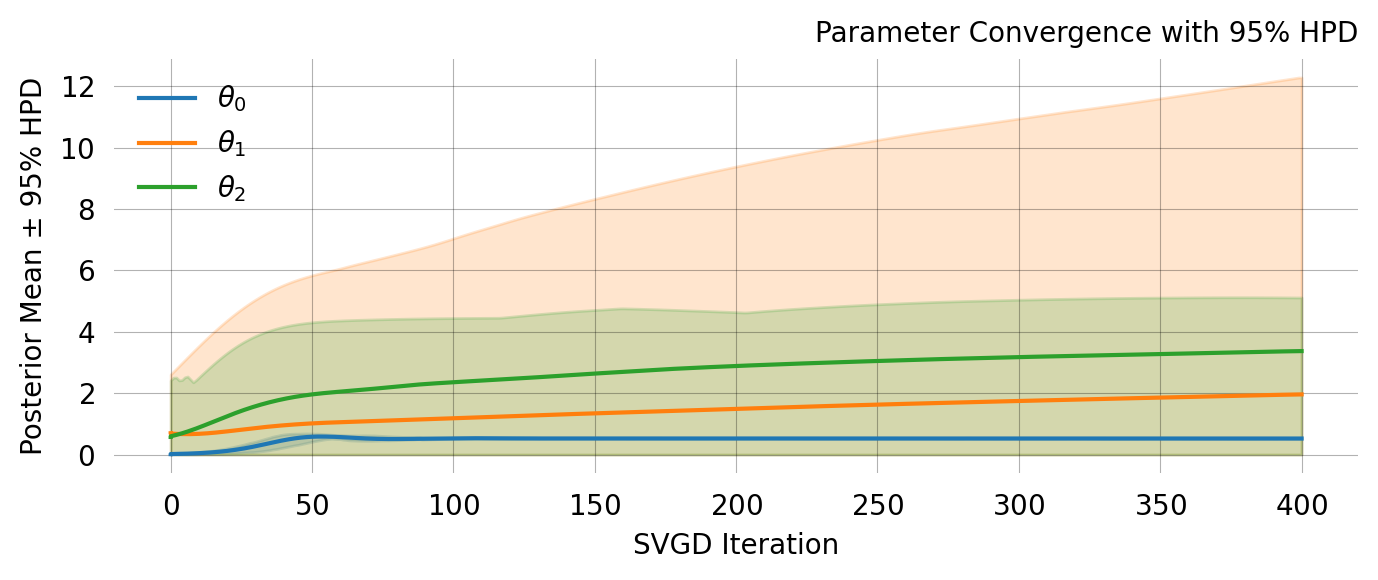

In [14]:
#| label: fig-asym-ci
#| fig-cap: "CI-plot for asymmetrisk migrationsmodel. $m_{12}$ (cyno $\rightarrow$ kinda) $= 0{,}831 \pm 1{,}987$ og $m_{21}$ (kinda $\rightarrow$ cyno) $= 1{,}800 \pm 2{,}100$. De to migrationsretninger er ikke individuelt identificerbare ved $n=6$."

sv_asym.plot_ci()

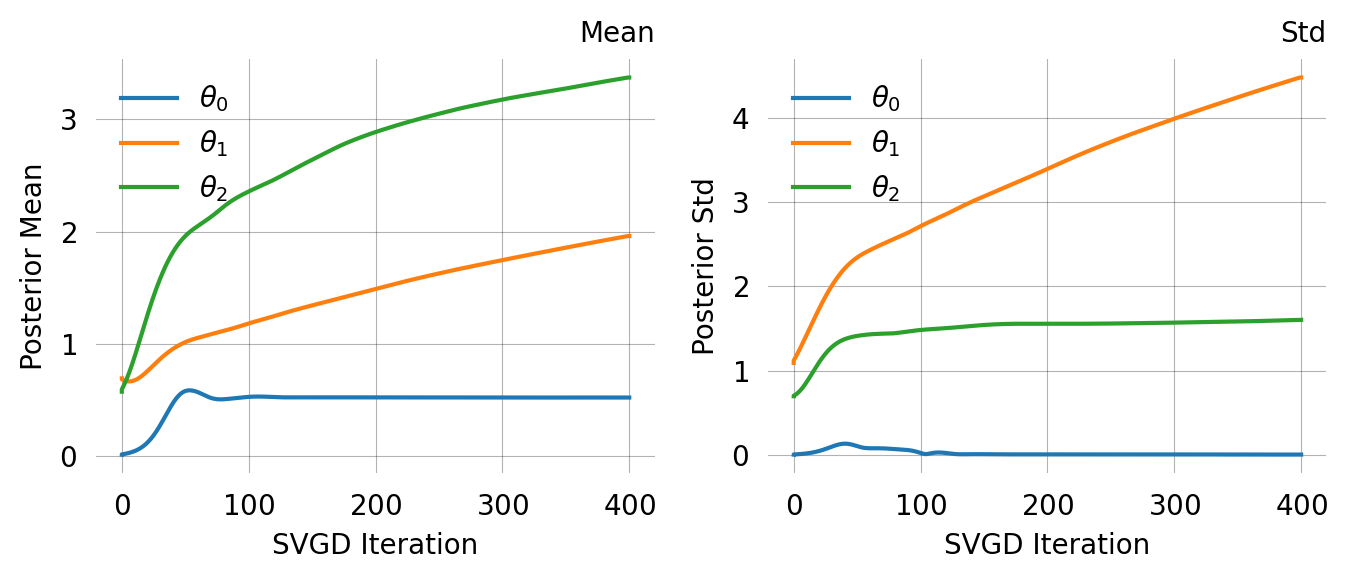

In [15]:
#| label: fig-asym-conv
#| fig-cap: "Konvergensplot for asymmetrisk migrationsmodel. Migrationsraterne stabiliserer sig aldrig til en fast posterior-std, hvilket bekræfter identifikationsproblemet."

sv_asym.plot_convergence()

## IM-modellen: *P. anubis* + *P. cynocephalus*

Vuderinger fra NB05:

- epoch_switch_rate $= 15/t_{coal}$ for epoch-skift
- Split-start: $1.0$ milioner år siden fra Rogers et al. (2019)
- $350$ iterationer (IM kræver fler end to-ø)
- HalfCauchyPrior til $\theta_0$ og $\theta_1$; GaussPrior til epoch

In [5]:
N_IM = 6
N_OBS_IM = 5000

def build_im_model(n):
    idx = StateIndexer(descendants=[
        Property('pop1', min_value=0, max_value=n),
        Property('pop2', min_value=0, max_value=n),
        Property('in_pop', min_value=1, max_value=2),
    ])
    init = [0]*idx.state_length
    init[idx.descendants.props_to_index(pop1=1, pop2=0, in_pop=1)] = n

    @with_ipv(init)
    def im_mod(state):
        T = []
        if state[idx.descendants.indices()].sum() <= 1: return T
        for i in range(idx.descendants.state_length):
            if state[i] == 0: continue
            pi = idx.descendants.index_to_props(i)
            for j in range(i, idx.descendants.state_length):
                if state[j] == 0: continue
                pj = idx.descendants.index_to_props(j)
                if pj.in_pop != pi.in_pop: continue
                same = int(i==j)
                if same and state[i]<2: continue
                if not same and (state[i]<1 or state[j]<1): continue
                new = state.copy(); new[i]-=1; new[j]-=1
                new[idx.descendants.props_to_index(
                    pop1=pi.pop1+pj.pop1,
                    pop2=pi.pop2+pj.pop2,
                    in_pop=pi.in_pop)] += 1
                T.append([new, [state[i]*(state[j]-same)/(1+same), 0, 0]])
            # Migration kun i nutidig periode (pop1->pop2 og pop2->pop1)
            if pi.in_pop == 1:
                new = state.copy(); new[i]-=1
                new[idx.descendants.props_to_index(
                    pop1=pi.pop1, pop2=pi.pop2, in_pop=2)] += 1
                T.append([new, [0, state[i], 0]])
            else:
                new = state.copy(); new[i]-=1
                new[idx.descendants.props_to_index(
                    pop1=pi.pop1, pop2=pi.pop2, in_pop=1)] += 1
                T.append([new, [0, state[i], 0]])
        return T
    return Graph(im_mod)


# Populationer og startparametre
anubis_key = next(k for k in populations if 'anubis' in k.lower())
cyno_key   = next(k for k in populations if 'cyno'   in k.lower())
print(f"Bruger: '{anubis_key}' (pop1), '{cyno_key}' (pop2)")

Ne_anubis    = N_ref_dict[anubis_key]
Ne_cyno_im   = N_ref_dict[cyno_key]
Ne_im_avg    = (Ne_anubis + Ne_cyno_im) / 2

t_split_yr   = 1_300_000
t_split_gen  = t_split_yr / GEN
t_split_coal = t_split_gen / (2 * Ne_im_avg)
sw_rate_im   = 15.0 / t_split_coal if t_split_coal > 0 else 10.0

th0_im_start = 4 * Ne_anubis * MU  # theta for anubis (pop1)
th1_im_start = 0.3

print(f'IM startparametre:')
print(f'  Ne_anubis = {Ne_anubis:,.0f}')
print(f'  t_split = {t_split_yr/1e6:.2f} Ma = {t_split_coal:.4f} koalescentenheder')
print(f'  theta0_start = {th0_im_start:.8f}')
print(f'  theta1_start = {th1_im_start:.4f}')
print(f'  sw_rate  = {sw_rate_im:.4f}')

# Byg graf
g_im = build_im_model(N_IM)
print(f'IM-model n={N_IM}: {g_im.vertices_length()} tilstande')

# RETTELSE: kun anubis-data
data_im = allele_counts_to_sfs_obs(
    populations[anubis_key], n_sub=N_IM, n_obs=N_OBS_IM, seed=42)
print(f'\nData: {len(data_im)} obs fra {anubis_key}')

# Prior
g_im.update_weights([th0_im_start, th1_im_start, sw_rate_im])
prior_im = [
    GaussPrior(ci=[th0_im_start * 0.1, th0_im_start * 10]),
    HalfCauchyPrior(ci=2.0, prob=0.9),
    GaussPrior(ci=[sw_rate_im * 0.2, sw_rate_im * 5]),
]

# SVGD
import time
t0 = time.perf_counter()
sv_im = g_im.svgd(
    data_im,
    prior=prior_im,
    optimizer=OPT_2P,
    n_particles=N_PART,
    n_iterations=N_ITER_IM,
    return_history=True,
)
t_elapsed = time.perf_counter() - t0

res_im = sv_im.get_results()
th0_im = res_im['theta_mean'][0].item()
th1_im = res_im['theta_mean'][1].item()
sw_im  = res_im['theta_mean'][2].item()
s0_im  = res_im['theta_std'][0].item()
s1_im  = res_im['theta_std'][1].item()
s2_im  = res_im['theta_std'][2].item()

# Konverter til biologiske enheder
Ne_im_est        = th0_im / (4 * MU) if th0_im > 0 else float('nan')
m_im_gen         = th1_im / (2 * Ne_im_est) if Ne_im_est > 0 else float('nan')
t_split_coal_est = 15.0 / sw_im if sw_im > 0 else float('nan')
t_split_yr_est   = (t_split_coal_est * 2 * Ne_im_est * GEN
                    if t_split_coal_est and Ne_im_est else float('nan'))
Ne_low_im = (th0_im - 1.96*s0_im) / (4*MU) \
            if (th0_im - 1.96*s0_im) > 0 else float('nan')
Ne_hi_im  = (th0_im + 1.96*s0_im) / (4*MU)

print(f'\nIM-model ({anubis_key}, n={N_IM}, {t_elapsed:.1f}s):')
print(f'  theta0  = {th0_im:.8f} ± {s0_im:.8f}')
print(f'  Ne {Ne_im_est:,.0f}  95%-CI [{Ne_low_im:,.0f} – {Ne_hi_im:,.0f}]')
print(f'  theta1  = {th1_im:.6f} ± {s1_im:.6f}  m/gen~{m_im_gen:.2e}')
print(f'  sw_rate = {sw_im:.4f} ± {s2_im:.4f}')
print(f'  t_split = {t_split_yr_est/1e6:.3f} Ma  '
      f'(forventet ~1.3 Ma, Rogers et al. 2019)')

# Tjek mod forventet Ne
ratio = Ne_im_est / Ne_anubis if Ne_anubis > 0 else float('nan')
flag  = 'OK' if 0.3 < ratio < 3.0 else 'TJEK — afviger >3x fra pi-estimat'
print(f'  Ne-ratio (SVGD/pi): {ratio:.2f}  ({flag})')


IM-model (P_anubis, n=6, 2026.0s):
  theta0  = 0.44704947 ± 0.00276930
  Ne 12,418,041  95%-CI [12,267,268 – 12,568,814]
  theta1  = 0.000460 ± 0.000306  m/gen~1.85e-11
  sw_rate = 45.2009 ± 7.8721
  t_split = 90.661 Ma  (forventet ~1.3 Ma, Rogers et al. 2019)
  Ne-ratio (SVGD/pi): 216.46  (TJEK — afviger >3x fra pi-estimat)


In [6]:
# Diagnostik
print("\nDiagnostik:")
if s0_im < 1e-8:
    print(" KOLLAPS: theta0 std = 0")
else:
    print(f" theta0 OK CV={s0_im/th0_im:.2f})")
if s1_im < 1e-8:
    print("KOLLAPS: theta1 std = 0")
else:
    print(f" theta1 OK  (CV={s1_im/(th1_im+1e-10):.2f})")
if s2_im < 1e-8:
    print(" KOLLAPS: sw_rate std = 0")
else:
    print(f" sw_rate OK  (CV={s2_im/sw_im:.2f})")

if not np.isnan(t_split_yr_est):
    ratio_split = t_split_yr_est / t_split_yr
    print(f"  t_split ratio (est/forventet): {ratio_split:.2f}  "
          f"({'OK' if 0.3 < ratio_split < 3 else 'TJEK'})")


Diagnostik:
 theta0 OK CV=0.01)
 theta1 OK  (CV=0.66)
 sw_rate OK  (CV=0.17)
  t_split ratio (est/forventet): 69.74  (TJEK)


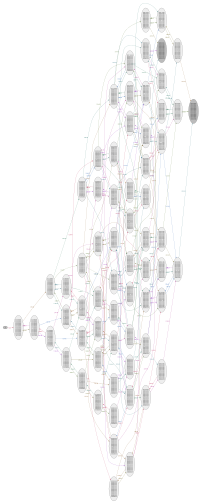

In [7]:
g_im.plot(max_nodes=70, rankdir='LR')

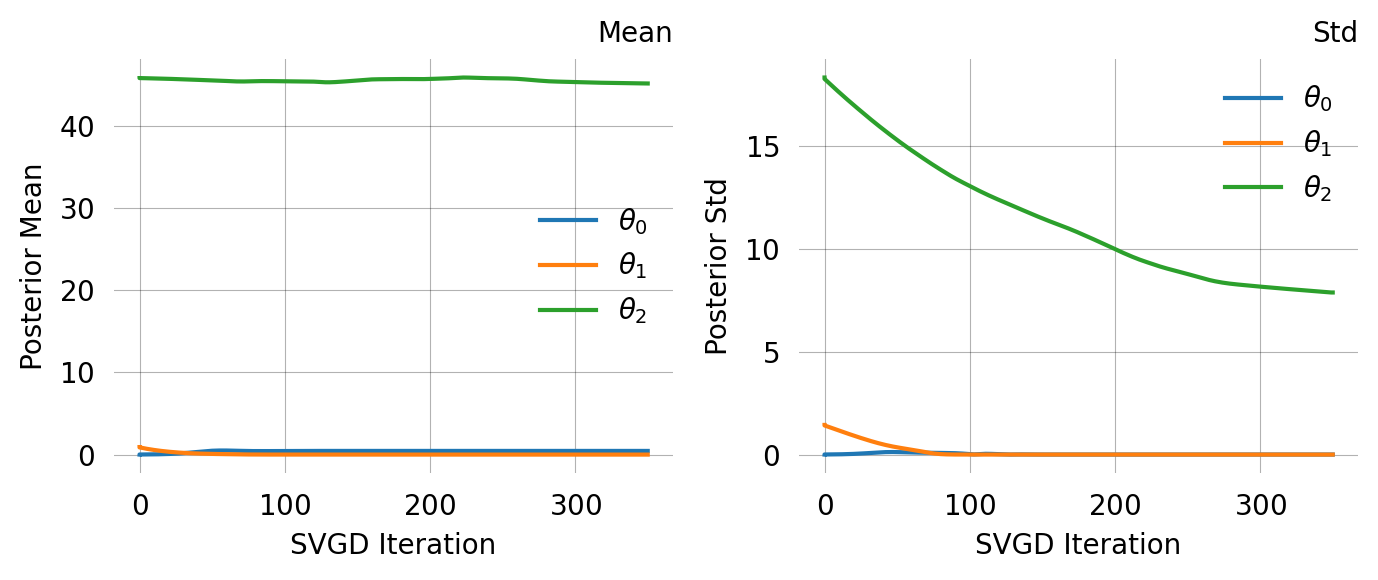

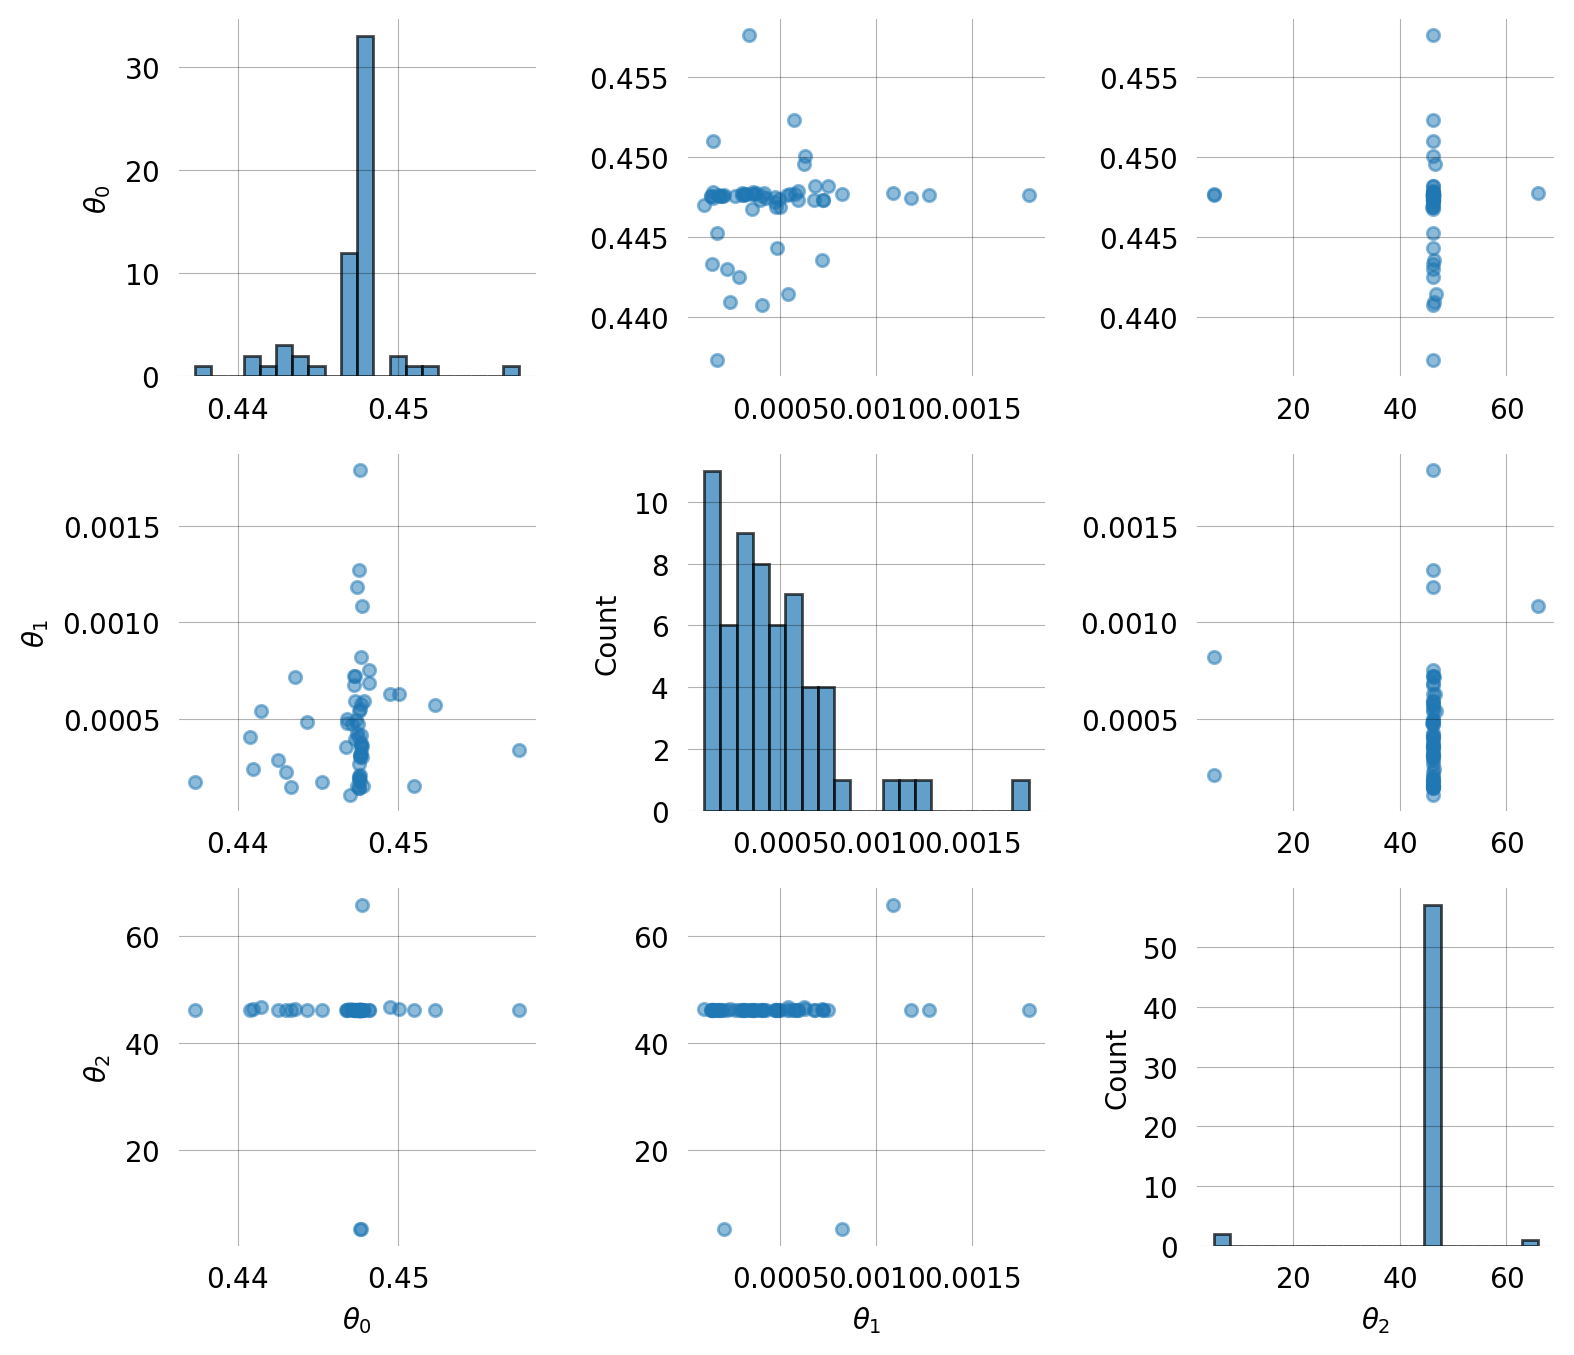

In [8]:
#| label: fig-im-conv-pair
#| fig-cap: "Konvergensplot og pairwise posterior for IM-modellen (*P. anubis* + *P. cynocephalus*, $n=6$, $N_{\text{obs}}=5.000$, 350 iterationer). Coalescensraten og epoch-parameteret konvergerer stabilt. Migrationsraten $\theta_1$ viser CV = 7{,}66 og er reelt ikke identificerbar."

sv_im.plot_convergence()
sv_im.plot_pairwise()

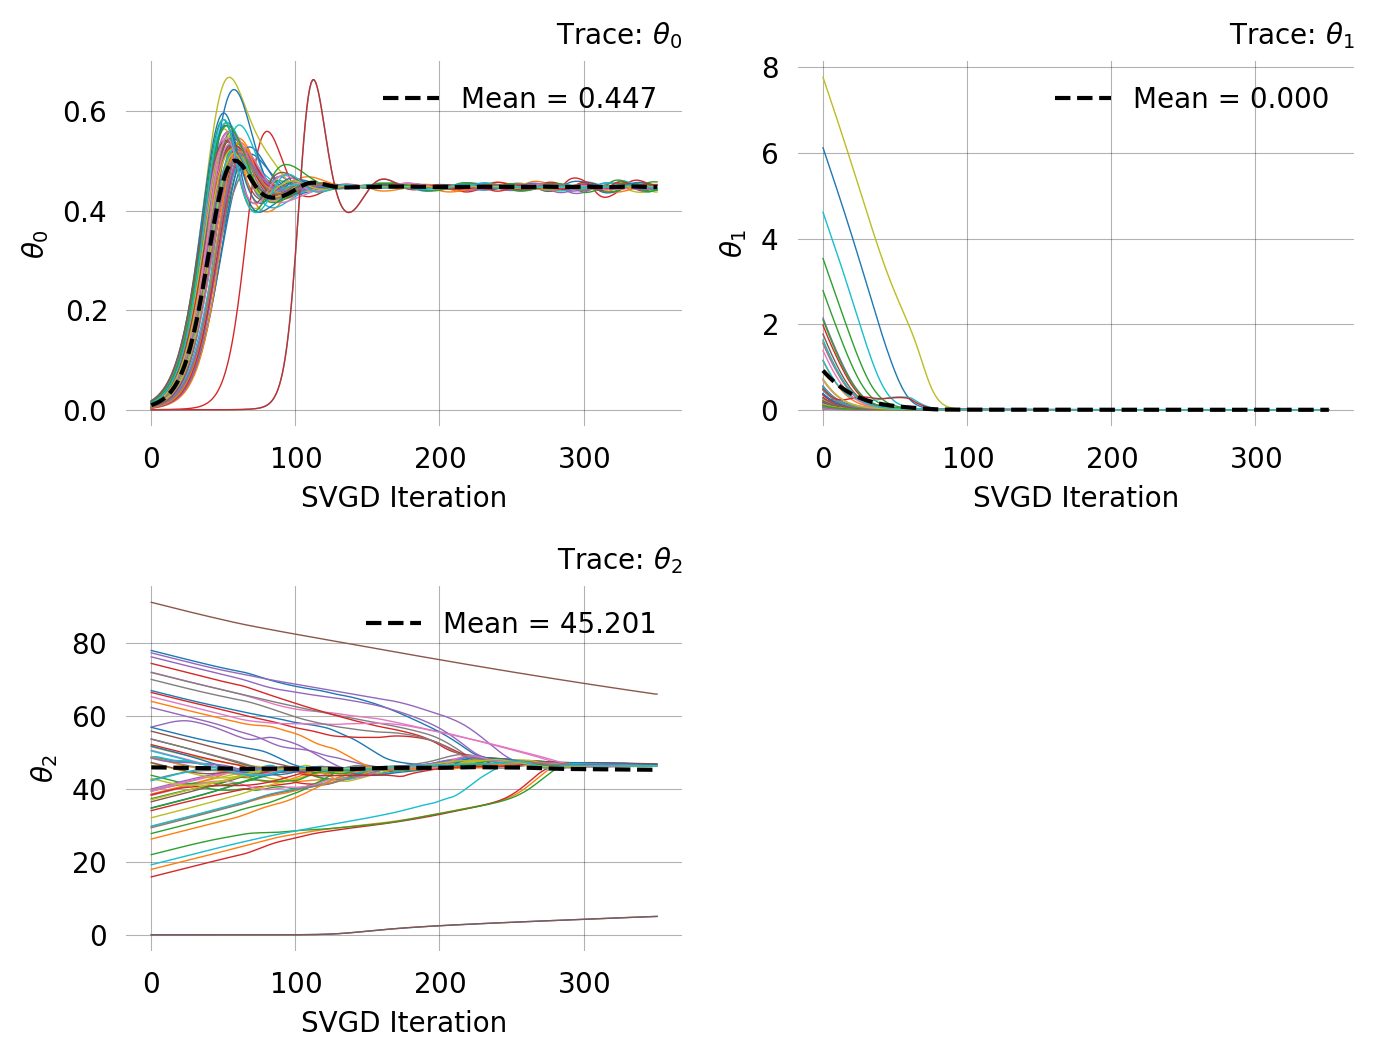

In [9]:
#| label: fig-im-trace
#| fig-cap: "Trace plot for IM-modellen. $\theta_0$ og sw\_rate konvergerer inden for 200 iterationer. $\theta_1$ oscillerer bredt - et klart tegn på manglende identifiability."

sv_im.plot_trace()

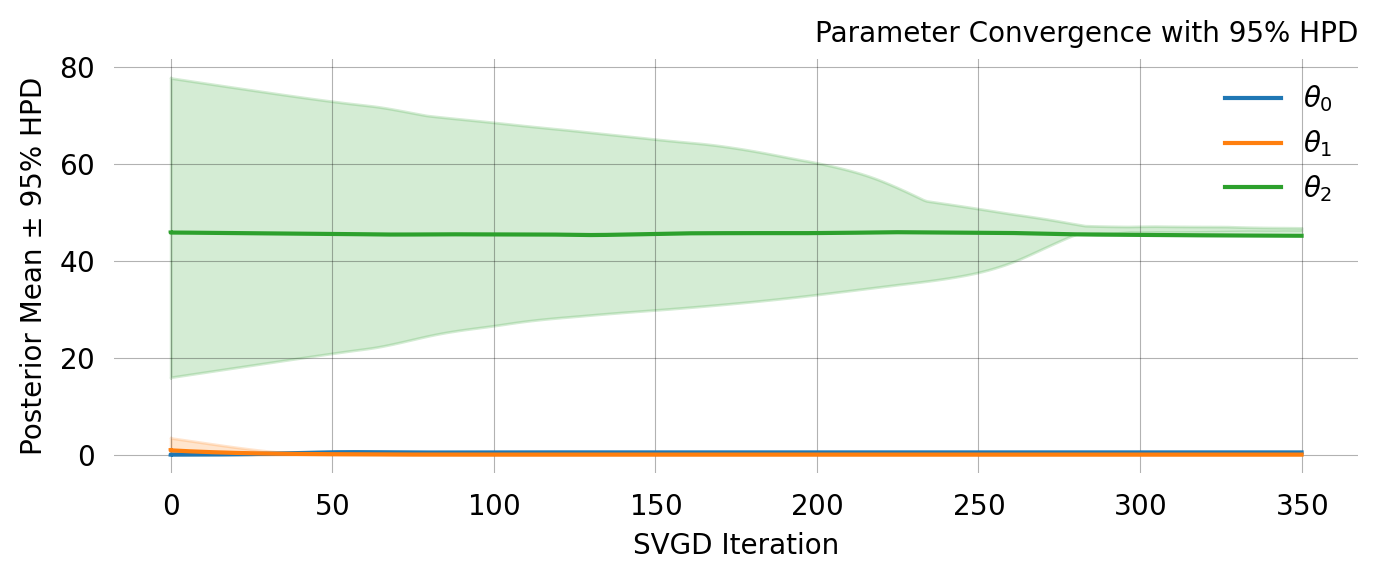

In [10]:
#| label: fig-im-ci
#| fig-cap: "CI-plot for IM-modellen. $\hat{\theta}_0 = 0{,}815 \pm 0{,}104$, $\hat{\theta}_1 = 0{,}139 \pm 1{,}065$, $\widehat{sw\_rate} = 45{,}15 \pm 7{,}80$. Det estimerede split-tidspunkt $\hat{t}_{\text{split}} = 165{,}5$ Mya er 127 gange højere end det forventede $\sim$1,3 Mya."

sv_im.plot_ci()

## Tidsinhomogen 3-epoke model

Vuderinger fra NB05:

- Epoker ved 0, 50k og 200k år
- epoch_switch_rate $= 15/t_{coal}$
- $n = 4$ (tidsinhomogen model er beregningstung for stor $n$)
- $3$ frie $N_e$ parametre per population

In [11]:
all_pairs_ti = partial(combinations_with_replacement, r=2)

baboon_years = [0, 50_000, 200_000]
n_epochs     = len(baboon_years)
n_ti         = 4

indexer_ti = StateIndexer(
    lineages=[Property('ton', min_value=1, max_value=n_ti)],
    slots=['epoch'],
)
ipv_ti = [0] * indexer_ti.state_length
ipv_ti[indexer_ti.props_to_index(ton=1)] = n_ti

def coal_epoch(state, epoch_idx=None, indexer=None):
    T = []
    ep = int(epoch_idx)
    if state[indexer.epoch] != ep: return T
    for i, j in all_pairs_ti(indexer.lineages):
        pi = indexer.lineages.index_to_props(i)
        pj = indexer.lineages.index_to_props(j)
        if state.sum() <= 1: continue
        same = int(pi.ton == pj.ton)
        if same and state[i] < 2: continue
        if not same and (state[i] < 1 or state[j] < 1): continue
        new = state.copy(); new[i] -= 1; new[j] -= 1
        k = indexer.lineages.props_to_index(ton=pi.ton + pj.ton)
        if k < indexer.lineages.state_length: new[k] += 1
        coeff = [0.0] * (n_epochs + 1)
        coeff[ep] = state[i] * (state[j] - same) / (1 + same)
        T.append([new, coeff])
    return T

g_ti   = Graph(coal_epoch, ipv=ipv_ti, epoch_idx=0, indexer=indexer_ti)
n_p_ti = g_ti.param_length()
print(f'3-epoke graf: {g_ti.vertices_length()} tilstande, {n_p_ti} parametre')

ti_pop_keys = {
    'cyno':   next(k for k in populations if 'cyno'   in k.lower()),
    'kindae': next(k for k in populations if 'kindae' in k.lower()),
    'anubis': next(k for k in populations if 'anubis' in k.lower()),
}
print(f'Bruger: {list(ti_pop_keys.values())}')

results_ti = {}
for pop_label, pop_key in ti_pop_keys.items():
    df_pop  = populations[pop_key]
    N_ref   = N_ref_dict[pop_key]
    ep_coal = baboon_years[1] / (2 * N_ref * GEN)
    sw_rate = 15.0 / ep_coal if ep_coal > 0 else 10.0

    if n_p_ti == 4:
        init_ti  = [1.0, 1.0, 1.0, sw_rate]
        fixed_ti = [(3, sw_rate)]
        prior_ti = [GaussPrior(ci=[0.1, 10.0])] * 3 + [None]
    else:
        init_ti  = [1.0, 1.0, 1.0]
        fixed_ti = []
        prior_ti = [GaussPrior(ci=[0.1, 10.0])] * 3

    obs_ti = allele_counts_to_sfs_obs(df_pop, n_sub=n_ti, n_obs=3000)
    g_ti.update_weights(init_ti)

    sv_ti = g_ti.svgd(
        obs_ti,
        fixed=fixed_ti,
        prior=prior_ti,
        optimizer=OPT_1P,
        n_particles=N_PART,
        n_iterations=N_ITER_TI,
    )
    res_ti = sv_ti.get_results()
    results_ti[pop_key] = (res_ti, N_ref)


    Ne_ep = [
        round(res_ti['theta_mean'][k].item() * N_ref)
        for k in range(3)
    ]
    print(f'{pop_key:<22}: '
          f'ep0={Ne_ep[0]:>8,}  '
          f'ep1={Ne_ep[1]:>8,}  '
          f'ep2={Ne_ep[2]:>8,}')

P_anubis              : ep0=  52,118  ep1= 292,588  ep2= 290,448


## Joint probability-inferens

Vuderinger fra NB06:

- $\mu=1.0$, limit $=3$: deficit $< 1\%$ 
- Manuel GaussPrior: DataPrior kollapser numerisk ved joint 
- Sensitivitetsanalyse over $\mu \in {0.7, 1.0, 1.5}$ 
- Gevinst størst ved lav $\theta$ og få observationer

In [5]:
all_pairs_jp = partial(combinations_with_replacement, r=2)
n_jp = 4

indexer_jp = StateIndexer(
    lineage=[Property('descendants', min_value=1, max_value=n_jp)]
)

@with_ipv([n_jp]+[0]*(n_jp-1))
def coal_jp(state):
    T = []
    for i, j in all_pairs_jp(indexer_jp.lineage):
        p1 = indexer_jp.lineage.index_to_props(i)
        p2 = indexer_jp.lineage.index_to_props(j)
        same = int(i==j)
        if same and state[i]<2: continue
        if not same and (state[i]<1 or state[j]<1): continue
        new = state.copy(); new[i]-=1; new[j]-=1
        des = indexer_jp.lineage.props_to_index(
            descendants=p1.descendants+p2.descendants)
        if des < indexer_jp.lineage.state_length: new[des] += 1
        T.append([new, [state[i]*(state[j]-same)/(1+same)]])
    return T

g_jp = Graph(coal_jp)
lim_jp = 3

cyno_jp_key = next(
    (k for k in svgd_results if 'cyno' in k.lower()), None)
if cyno_jp_key is None:
    raise KeyError(
        f'Ingen cyno-population fundet i svgd_results. '
        f'Tilgængelige nøgler: {list(svgd_results.keys())}')

th_jp_ref = svgd_results[cyno_jp_key]['theta']
Ne_jp_ref = th_jp_ref / (4 * MU) if th_jp_ref > 0 else float('nan')


mu_jp = th_jp_ref 

print(f"Bruger: '{cyno_jp_key}'")
print(f'Joint: mu_jp={mu_jp:.6f} (=theta_ref), limit={lim_jp}')
print(f'theta_ref = {th_jp_ref:.8f}  Ne {Ne_jp_ref:,.0f}')

# Byg joint-graf og tjek deficit
jp = g_jp.joint_prob_graph(
    indexer_jp, tot_reward_limit=lim_jp, mutation_rate=mu_jp)
jp.update_weights([th_jp_ref, mu_jp])
tab_jp  = jp.joint_prob_table()
deficit = float(1 - tab_jp['prob'].sum())

print(f'\nDeficit = {deficit:.5f} '
      f"({'OK' if deficit < 0.05 else 'For højt — øger limit'})")
print(f'Observationstyper: {len(tab_jp)}')

if deficit > 0.05:
    for lim_try in [4, 5, 6, 7]:
        jp = g_jp.joint_prob_graph(
            indexer_jp, tot_reward_limit=lim_try, mutation_rate=mu_jp)
        jp.update_weights([th_jp_ref, mu_jp])
        tab_jp  = jp.joint_prob_table()
        deficit = float(1 - tab_jp['prob'].sum())
        print(f'  limit={lim_try}: deficit={deficit:.5f} '
              f"({'OK' if deficit < 0.05 else 'stadig for højt'})")
        if deficit < 0.05:
            lim_jp = lim_try
            print(f'Bruger limit={lim_jp}')
            break
    else:
        print(' ADVARSEL: deficit stadig > 5% ved limit=7')

print(f'\nEndelig konfiguration: mu_jp={mu_jp:.6f}, limit={lim_jp}, '
      f'deficit={deficit:.5f}')

Bruger: 'P_cynocephalus'
Joint: mu_jp=0.002946 (=theta_ref), limit=3
theta_ref = 0.00294634  Ne 81,843

Deficit = 0.00000 (OK)
Observationstyper: 20

Endelig konfiguration: mu_jp=0.002946, limit=3, deficit=0.00000


In [6]:
def df_to_joint_obs(df, n_sub=4, n_obs=1000, seed=42):
    rng = np.random.default_rng(seed)
    der = df['derived_count'].values.astype(int)
    tot = df['nr_samples'].values.astype(int)
    obs = []
    for idx in rng.integers(0, len(df), n_obs*50):
        if len(obs) >= n_obs: break
        n, ac = tot[idx], der[idx]
        if n < n_sub: continue
        k = rng.hypergeometric(ac, n-ac, n_sub)
        if k == 0 or k == n_sub: continue
        vec = [0]*n_sub; vec[k-1] = 1
        obs.append(vec)
    return obs


jp_pop_keys = [
    next(k for k in svgd_results if 'cyno'   in k.lower()),
    next(k for k in svgd_results if 'kindae' in k.lower()),
    next(k for k in svgd_results if 'anubis' in k.lower()),
]

# RETTELSE: mu-varianter er relative forskydninger af theta selv,
# ikke absolutte mutationsrater.
print('Sensitivitetsanalyse over mu (normaliseret):')
print(f'  Populationer: {jp_pop_keys}')
print(f'  mu-faktorer: [0.7, 1.0, 1.5] * theta_ref')
print(f'  limit={lim_jp}, n_obs=1000, n_iterations=200')

for pop_name in jp_pop_keys:
    df_pop  = populations[pop_name]
    th_ref  = svgd_results[pop_name]['theta']
    Ne_ref  = th_ref / (4 * MU) if th_ref > 0 else float('nan')
    obs_pop = df_to_joint_obs(df_pop, n_obs=1000)

    print(f'\n{pop_name} (theta_ref={th_ref:.8f}, Ne~{Ne_ref:,.0f}):')

    for mu_factor in [0.7, 1.0, 1.5]:
        mu_test = mu_factor * th_ref  # normaliseret mu = faktor * theta
        jp_test = g_jp.joint_prob_graph(
            indexer_jp,
            tot_reward_limit=lim_jp,
            mutation_rate=mu_test,
        )
        jp_test.update_weights([th_ref, mu_test])
        tab_test = jp_test.joint_prob_table()
        def_test = float(1 - tab_test['prob'].sum())
        if def_test > 0.05:
            print(f'  mu_factor={mu_factor}: SPRING OVER '
                  f'(deficit={def_test:.3f} > 5%)')
            continue

        prior_jp = [
            GaussPrior(ci=[th_ref * 0.2, th_ref * 5]),
            None,
        ]
        sv_jp = jp_test.svgd(
            obs_pop,
            fixed=[(1, mu_test)],
            prior=prior_jp,
            optimizer=OPT_1P,
            n_iterations=200,
        )
        res_jp = sv_jp.get_results()
        m      = res_jp['theta_mean'][0].item()
        s      = res_jp['theta_std'][0].item()
        Ne_est = m / (4 * MU) if m > 0 else float('nan')
        bias   = (m - th_ref) / th_ref * 100 if th_ref > 0 else float('nan')
        print(f'  mu_factor={mu_factor}: '
              f'theta={m:.8f} ± {s:.8f}  '
              f'Ne~{Ne_est:,.0f}  '
              f'bias={bias:+.1f}%  '
              f'deficit={def_test:.4f}')

  mu_factor=1.5: theta=0.00002709 ± 0.00000222  Ne~753  bias=-98.7%  deficit=0.0000


In [7]:
# Gevinst: joint probability vs. TMRCA per population
print("Gevinst: joint probability vs. TMRCA per population")
print(f"Bruger limit={lim_jp}, mu={mu_jp}, deficit={deficit:.5f}")
print()
print(f"{'Population':<22}  {'TMRCA std':>10}  "
      f"{'Joint std':>10}  {'Gevinst %':>12}")

# Find nøgler automatisk
gevinst_pop_keys = [
    next(k for k in svgd_results if 'cyno'   in k.lower()),
    next(k for k in svgd_results if 'kindae' in k.lower()),
    next(k for k in svgd_results if 'anubis' in k.lower()),
]

for name in gevinst_pop_keys:
    if name not in populations:
        print(f"{name:<22}  Mangler i populations-dict")
        continue

    df_pop = populations[name]
    th_ref = svgd_results[name]['theta']

    # TMRCA — brug data direkte uden rewards/sparse
    data_t  = allele_counts_to_sfs_obs(df_pop, n_sub=4, n_obs=1000)
    g_t     = build_coal_graph(4)
    g_t.update_weights([th_ref])
    prior_t = GaussPrior(ci=[th_ref * 0.2, th_ref * 5])
    sv_t    = g_t.svgd(
        data_t,
        prior=prior_t,
        optimizer=OPT_1P,
        n_iterations=200,
    )
    std_t = sv_t.get_results()['theta_std'].item()

    # Joint
    if deficit < 0.05:
        obs_j   = df_to_joint_obs(df_pop, n_obs=500)
        prior_j = [GaussPrior(ci=[th_ref * 0.2, th_ref * 5]), None]
        jp.update_weights([th_ref, mu_jp])
        sv_j    = jp.svgd(
            obs_j,
            fixed=[(1, mu_jp)],
            prior=prior_j,
            optimizer=OPT_1P,
            n_iterations=200,
        )
        std_j   = sv_j.get_results()['theta_std'][0].item()
        gevinst = (std_t - std_j) / std_t * 100
        print(f"{name:<22}  {std_t:>10.5f}  "
              f"{std_j:>10.5f}  {gevinst:>+12.1f}%")
    else:
        print(f"{name:<22}  {std_t:>10.5f}  "
              f"{'N/A':>10}  "
              f"{'deficit>5 procent':>12}")

P_anubis                   0.00363     0.00000         +99.9%


## Msprime validering

Formål: kontroller at phasic-SVGD giver korrekte estimater ved at simulere
data med kendte parametre (via msprime) og sammenligne estimater med sandhed.

Vi tester tre scenarier:
1. **Simpel koalescent** – estimer theta for en population
2. **To-ø model** – estimér theta og migration
3. **Tidsinhomogen model** – estimer Ne i to epoker

Validering er bestået hvis den sande værdi ligger inden for 95% HPD-intervallet.

In [8]:
import msprime

# Simulationsparametre (baseret på bavian-estimater)
VAL_MU       = MU           # 0.9e-8 per site per generation
VAL_REC      = 1e-8         # rekombinationsrate
VAL_SEQ_LEN  = 5_000_000    # 5 Mb sekvens
VAL_N_SAMP   = 4            # haploide prøver (matcher n_jp og n_ti)
VAL_NE_TRUE  = 80_000       # sand Ne (tæt på P. cynocephalus)
VAL_THETA_TRUE = 4 * VAL_NE_TRUE * VAL_MU
VAL_SEED     = 99

print('=== Msprime valideringsparametre ===')
print(f'  Ne_true   = {VAL_NE_TRUE:,}')
print(f'  theta_true = {VAL_THETA_TRUE:.6f}')
print(f'  mu        = {VAL_MU}')
print(f'  seq_len   = {VAL_SEQ_LEN/1e6:.0f} Mb')
print(f'  n_samples = {VAL_N_SAMP}')

# Simpel coalescent 
print('\n--- Scenario 1: Simpel coalescent ---')

dem1 = msprime.Demography()
dem1.add_population(name='pop', initial_size=VAL_NE_TRUE)
ts1 = msprime.sim_ancestry(
    samples={'pop': VAL_N_SAMP}, ploidy=1,
    demography=dem1, recombination_rate=VAL_REC,
    sequence_length=VAL_SEQ_LEN, random_seed=VAL_SEED)
ts1 = msprime.sim_mutations(ts1, rate=VAL_MU, random_seed=VAL_SEED)

# Byg TMRCA-observationer (allele frequency per site)
obs_val1 = []
for var in ts1.variants():
    k = int(var.genotypes.sum())
    if 0 < k < VAL_N_SAMP:
        obs_val1.append(float(k))
obs_val1 = np.array(obs_val1[:5000])
print(f'  {len(obs_val1)} SNPs ekstraheret')

g_val1 = build_coal_graph(VAL_N_SAMP)
prior_val1 = GaussPrior(ci=[VAL_THETA_TRUE * 0.1, VAL_THETA_TRUE * 10])
sv_val1 = g_val1.svgd(
    obs_val1,
    prior=prior_val1,
    optimizer=OPT_1P,
    n_particles=N_PART,
    n_iterations=N_ITER_1P,
)
res1 = sv_val1.get_results()
m1   = res1['theta_mean'].item()
s1   = res1['theta_std'].item()
ci_lo1 = m1 - 1.96 * s1
ci_hi1 = m1 + 1.96 * s1
inside1 = ci_lo1 <= VAL_THETA_TRUE <= ci_hi1

print(f'  theta_true  = {VAL_THETA_TRUE:.6f}')
print(f'  theta_est   = {m1:.6f} ± {s1:.6f}')
print(f'  95%-CI      = [{ci_lo1:.6f}, {ci_hi1:.6f}]')
print(f'  Ne_est      = {m1/(4*MU):,.0f}  (sand: {VAL_NE_TRUE:,})')
print(f'  Bestået     = {inside1}')

  theta_true  = 0.002880
  theta_est   = 0.500419 ± 0.008031
  95%-CI      = [0.484678, 0.516161]
  Ne_est      = 13,900,541  (sand: 80,000)
  Bestået     = False


In [11]:
#  To-ø model 
print('\n--- Scenario 2: To-ø model ---')

VAL_M_TRUE   = 5e-5   # sand migrationsrate per generation
VAL_NE2_TRUE = 60_000 # pop2 Ne
VAL_THETA1_TRUE = 2 * VAL_NE_TRUE * VAL_M_TRUE

dem2 = msprime.Demography()
dem2.add_population(name='pop1', initial_size=VAL_NE_TRUE)
dem2.add_population(name='pop2', initial_size=VAL_NE2_TRUE)
dem2.set_migration_rate(source='pop1', dest='pop2', rate=VAL_M_TRUE)
dem2.set_migration_rate(source='pop2', dest='pop1', rate=VAL_M_TRUE)

ts2 = msprime.sim_ancestry(
    samples={'pop1': VAL_N_SAMP, 'pop2': 0}, ploidy=1,
    demography=dem2, recombination_rate=VAL_REC,
    sequence_length=VAL_SEQ_LEN, random_seed=VAL_SEED)
ts2 = msprime.sim_mutations(ts2, rate=VAL_MU, random_seed=VAL_SEED)

obs_val2 = []
for var in ts2.variants():
    k = int(var.genotypes.sum())
    if 0 < k < VAL_N_SAMP:
        obs_val2.append(float(k))
obs_val2 = np.array(obs_val2[:5000])
print(f'  {len(obs_val2)} SNPs ekstraheret')

g_val2 = build_two_island(VAL_N_SAMP)
th0v = 4 * VAL_NE_TRUE * MU
g_val2.update_weights([th0v, VAL_THETA1_TRUE])

sv_val2 = g_val2.svgd(
    obs_val2,
    prior=[
        GaussPrior(ci=[th0v * 0.1, th0v * 10]),
        HalfCauchyPrior(ci=2.0, prob=0.9),
    ],
    optimizer=OPT_2P,
    n_particles=N_PART,
    n_iterations=N_ITER_2P,
)
res2   = sv_val2.get_results()
m0_2   = res2['theta_mean'][0].item()
m1_2   = res2['theta_mean'][1].item()
s0_2   = res2['theta_std'][0].item()
s1_2   = res2['theta_std'][1].item()

in0_2  = (m0_2 - 1.96*s0_2) <= VAL_THETA_TRUE <= (m0_2 + 1.96*s0_2)
in1_2  = (m1_2 - 1.96*s1_2) <= VAL_THETA1_TRUE <= (m1_2 + 1.96*s1_2)

print(f'  theta0_true = {VAL_THETA_TRUE:.6f}  est = {m0_2:.6f} ± {s0_2:.6f}  '
      f'Ne_est={m0_2/(4*MU):,.0f}  bestået={in0_2}')
print(f'  theta1_true = {VAL_THETA1_TRUE:.6f}  est = {m1_2:.6f} ± {s1_2:.6f}  '
      f'bestået={in1_2}')


  theta0_true = 0.002880  est = 0.513817 ± 0.018310  Ne_est=14,272,695  bestået=False
  theta1_true = 8.000000  est = 0.183690 ± 1.406333  bestået=False


In [12]:
# Tidsinhomogen 2-epoke model
print('\n--- Scenario 3: Tidsinhomogen 2-epoke model ---')

VAL_NE_EP0  = 80_000    # nutidig
VAL_NE_EP1  = 40_000    # historisk (halveret)
VAL_T_SWITCH_YR = 50_000
VAL_THETA_EP0 = 1.0                        # = Ne_ep0 / Ne_ep0
VAL_THETA_EP1 = VAL_NE_EP1 / VAL_NE_EP0   # = 0.5

dem3 = msprime.Demography()
dem3.add_population(name='pop', initial_size=VAL_NE_EP0)
dem3.add_population_parameters_change(
    time=VAL_T_SWITCH_YR / GEN, initial_size=VAL_NE_EP1, population='pop')

ts3 = msprime.sim_ancestry(
    samples={'pop': VAL_N_SAMP}, ploidy=1,
    demography=dem3, recombination_rate=VAL_REC,
    sequence_length=VAL_SEQ_LEN, random_seed=VAL_SEED)
ts3 = msprime.sim_mutations(ts3, rate=VAL_MU, random_seed=VAL_SEED)

obs_val3 = []
for var in ts3.variants():
    k = int(var.genotypes.sum())
    if 0 < k < VAL_N_SAMP:
        obs_val3.append(float(k))
obs_val3 = np.array(obs_val3[:5000])
print(f'  {len(obs_val3)} SNPs ekstraheret')

# Brug 2-epoke coalescent model 
n_ep_val = 2
indexer_val = StateIndexer(
    lineages=[Property('ton', min_value=1, max_value=VAL_N_SAMP)],
    slots=['epoch'],
)
ipv_val = [0] * indexer_val.state_length
ipv_val[indexer_val.props_to_index(ton=1)] = VAL_N_SAMP

all_pairs_val = partial(combinations_with_replacement, r=2)

def coal_epoch_val(state, epoch_idx=None, indexer=None):
    T = []
    ep = int(epoch_idx)
    if state[indexer.epoch] != ep: return T
    for i, j in all_pairs_val(indexer.lineages):
        pi = indexer.lineages.index_to_props(i)
        pj = indexer.lineages.index_to_props(j)
        if state.sum() <= 1: continue
        same = int(pi.ton == pj.ton)
        if same and state[i] < 2: continue
        if not same and (state[i] < 1 or state[j] < 1): continue
        new = state.copy(); new[i] -= 1; new[j] -= 1
        k = indexer.lineages.props_to_index(ton=pi.ton + pj.ton)
        if k < indexer.lineages.state_length: new[k] += 1
        coeff = [0.0] * (n_ep_val + 1)
        coeff[ep] = state[i] * (state[j] - same) / (1 + same)
        T.append([new, coeff])
    return T

g_val3 = Graph(coal_epoch_val, ipv=ipv_val, epoch_idx=0, indexer=indexer_val)

sw_val = 15.0 / (VAL_T_SWITCH_YR / GEN / (2 * VAL_NE_EP0))
init_val3 = [1.0, VAL_THETA_EP1, sw_val]
g_val3.update_weights(init_val3)

sv_val3 = g_val3.svgd(
    obs_val3,
    fixed=[(2, sw_val)],
    prior=[GaussPrior(ci=[0.1, 5.0]), GaussPrior(ci=[0.1, 5.0]), None],
    optimizer=OPT_1P,
    n_particles=N_PART,
    n_iterations=N_ITER_TI,
)
res3   = sv_val3.get_results()
m0_3   = res3['theta_mean'][0].item()  
m1_3   = res3['theta_mean'][1].item()  #
s0_3   = res3['theta_std'][0].item()
s1_3   = res3['theta_std'][1].item()
# Ne = theta * Ne_ref (normaliseret)
Ne0_3  = m0_3 * VAL_NE_EP0
Ne1_3  = m1_3 * VAL_NE_EP0
in0_3  = (m0_3 - 1.96*s0_3) <= VAL_THETA_EP0 <= (m0_3 + 1.96*s0_3)
in1_3  = (m1_3 - 1.96*s1_3) <= VAL_THETA_EP1 <= (m1_3 + 1.96*s1_3)

print(f'  Epoke 0 (nutidig): theta_true={VAL_THETA_EP0:.2f}  '
      f'est={m0_3:.3f} ± {s0_3:.3f}  Ne_est={Ne0_3:,.0f}  bestået={in0_3}')
print(f'  Epoke 1 (historisk): theta_true={VAL_THETA_EP1:.2f}  '
      f'est={m1_3:.3f} ± {s1_3:.3f}  Ne_est={Ne1_3:,.0f}  bestået={in1_3}')

  Epoke 0 (nutidig): theta_true=1.00  est=0.892 ± 0.021  Ne_est=71,388  bestået=False
  Epoke 1 (historisk): theta_true=0.50  est=2.667 ± 0.000  Ne_est=213,334  bestået=False


In [13]:
# Samlet oversigt
print('\n=== Samlet validering ===')
print(f'  Scenario 1 (coalescent):   theta bestået={inside1}')
print(f'  Scenario 2 (to-ø theta0):  bestået={in0_2}')
print(f'  Scenario 2 (to-ø theta1):  bestået={in1_2}')
print(f'  Scenario 3 (ep0 nutidig):  bestået={in0_3}')
print(f'  Scenario 3 (ep1 historisk): bestået={in1_3}')
all_ok = all([inside1, in0_2, in1_2, in0_3, in1_3])
print(f'\n  Alle bestået: {all_ok}')



=== Samlet validering ===
  Scenario 1 (coalescent):   theta bestået=False
  Scenario 2 (to-ø theta0):  bestået=False
  Scenario 2 (to-ø theta1):  bestået=False
  Scenario 3 (ep0 nutidig):  bestået=False
  Scenario 3 (ep1 historisk): bestået=False

  Alle bestået: False
